# Независимая final-test оценка

Notebook один раз оценивает зафиксированные `naive_zero`, ARIMA, LSTM и ARIMA-LSTM на final test. До первого запуска должны пройти все проверки качества. После открытия результатов модели, протокол, метрики и статистические сравнения не изменяются.

In [1]:
import sys
from collections.abc import Mapping
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.contracts import BPS_FACTOR  # noqa: E402
from evaluation.final_checkpoint import (  # noqa: E402
    build_final_fingerprint,
    run_final_test_pipeline,
)
from evaluation.final_metrics import (  # noqa: E402
    FINAL_MODELS,
    build_price_predictions,
    calculate_final_price_metrics,
    calculate_final_return_metrics,
    calculate_seed_return_metrics,
)
from evaluation.final_models import (  # noqa: E402
    FINAL_KEY_COLUMNS,
    FINAL_TEST_PROTOCOL,
    validate_final_dataset,
)
from evaluation.loading import DATASET_NAME, load_processed_snapshot  # noqa: E402
from evaluation.regimes import (  # noqa: E402
    REGIMES,
    build_volatility_regimes,
    calculate_regime_return_metrics,
)
from evaluation.statistics import (  # noqa: E402
    BOOTSTRAP_COLUMNS,
    DM_COLUMNS,
    MODEL_COMPARISONS,
    calculate_bootstrap_intervals,
    calculate_dm_results,
)
from models.lstm import LSTMTrainer  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "final_test"

## Снимок данных и зафиксированный протокол

Снимок загружается только после проверки манифеста и SHA-256. Ячейка подтверждает неизменяемые границы выборок, тикеры, seed и параметры статистического анализа до запуска моделей.

In [2]:
snapshot = load_processed_snapshot(PROJECT_ROOT / "data" / "processed")
files = snapshot.metadata.get("files")
assert isinstance(files, Mapping)
dataset_record = files.get(DATASET_NAME)
assert isinstance(dataset_record, Mapping)
dataset_sha256 = dataset_record.get("sha256")
assert isinstance(dataset_sha256, str) and len(dataset_sha256) == 64

dataset = validate_final_dataset(snapshot.dataset, FINAL_TEST_PROTOCOL)
expected_tickers = tuple(spec.ticker for spec in FINAL_TEST_PROTOCOL.ticker_specs)
assert expected_tickers == ("AAPL", "JPM", "SPY", "XOM")
assert FINAL_TEST_PROTOCOL.seeds == tuple(range(10))
assert FINAL_TEST_PROTOCOL.split_config.test_start == "2020-01-02"
assert FINAL_TEST_PROTOCOL.split_config.test_end == "2025-12-31"
assert FINAL_TEST_PROTOCOL.dm_lag == 20
assert FINAL_TEST_PROTOCOL.bootstrap_block == 21
assert FINAL_TEST_PROTOCOL.bootstrap_repetitions == 10_000
assert FINAL_TEST_PROTOCOL.bootstrap_seed == 42

split_summary = dataset.groupby(["ticker", "split"], sort=True).agg(
    observations=("target_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)
display(split_summary)
print(f"Dataset SHA-256: {dataset_sha256}")

observations first_target_date last_target_date
ticker split                                                      
AAPL   test                1508        2020-01-02       2025-12-31
       train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    test                1508        2020-01-02       2025-12-31
       train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    test                1508        2020-01-02       2025-12-31
       train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    test                1508        2020-01-02       2025-12-31
       train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31

Dataset SHA-256: b8a86c09a664bf303492fd2fc61bd53b73b27af5cf1c713a79e85cbba6de7bf4


## Возобновляемое построение final-test прогнозов

Дорогой этап сохраняет совместимые результаты в `artifacts/final_test/`. Повторный запуск проверяет fingerprint и продолжает только отсутствующие ARIMA-тикеры или LSTM seed; успешные части не обучаются повторно.

In [3]:
progress_state = {"initial_completed": 0, "started_at": perf_counter()}


def report_final_progress(completed: int, total: int, stage: str) -> None:
    if stage == "checkpoint":
        progress_state["initial_completed"] = completed
        progress_state["started_at"] = perf_counter()
    elapsed = perf_counter() - float(progress_state["started_at"])
    new_completed = completed - int(progress_state["initial_completed"])
    if completed == total:
        eta = "0.0 мин"
    elif new_completed > 0:
        eta = f"{(total - completed) * elapsed / new_completed / 60:.1f} мин"
    else:
        eta = "ожидаем первый новый результат"
    clear_output(wait=True)
    print(
        f"Final test: {completed}/{total} | этап: {stage} | "
        f"прошло {elapsed / 60:.1f} мин | ETA: {eta}"
    )

In [4]:
trainer = LSTMTrainer()
final_result = run_final_test_pipeline(
    dataset,
    dataset_sha256,
    CHECKPOINT_DIR,
    trainer,
    protocol=FINAL_TEST_PROTOCOL,
    progress=report_final_progress,
)

Final test: 84/84 | этап: residual_lstm:XOM:09 | прошло 147.5 мин | ETA: 0.0 мин


## Полнота, выравнивание и отсутствие утечки

До расчёта метрик проверяются fingerprint, полные границы test, четыре модели, четыре тикера, одинаковые ключи и десять seed каждого LSTM-семейства.

In [7]:
expected_fingerprint = build_final_fingerprint(dataset_sha256, FINAL_TEST_PROTOCOL)
assert final_result.fingerprint == expected_fingerprint
predictions = final_result.predictions
assert set(predictions["model"]) == set(FINAL_MODELS)
assert set(predictions["ticker"]) == set(expected_tickers)
assert predictions["split"].eq("test").all()
assert np.isfinite(predictions[["actual_return", "predicted_return"]]).all().all()

test_ranges = predictions.groupby(["model", "ticker"], sort=True).agg(
    observations=("actual_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)
assert test_ranges["first_target_date"].eq(pd.Timestamp("2020-01-02")).all()
assert test_ranges["last_target_date"].eq(pd.Timestamp("2025-12-31")).all()
assert test_ranges["observations"].groupby(level="ticker").nunique().eq(1).all()

alignment_columns = [*FINAL_KEY_COLUMNS, "actual_return"]
baseline_keys = (
    predictions.loc[predictions["model"].eq("naive_zero"), alignment_columns]
    .sort_values(list(FINAL_KEY_COLUMNS), kind="mergesort")
    .reset_index(drop=True)
)
for model in FINAL_MODELS[1:]:
    model_keys = (
        predictions.loc[predictions["model"].eq(model), alignment_columns]
        .sort_values(list(FINAL_KEY_COLUMNS), kind="mergesort")
        .reset_index(drop=True)
    )
    pd.testing.assert_frame_equal(model_keys, baseline_keys)

baseline_calendar = baseline_keys.loc[
    baseline_keys["ticker"].eq("AAPL"), ["date", "target_date"]
].reset_index(drop=True)
for ticker in expected_tickers[1:]:
    ticker_calendar = baseline_keys.loc[
        baseline_keys["ticker"].eq(ticker), ["date", "target_date"]
    ].reset_index(drop=True)
    pd.testing.assert_frame_equal(ticker_calendar, baseline_calendar)

seed_result_groups = (
    final_result.lstm_seed_results,
    final_result.residual_seed_results,
    final_result.hybrid_seed_results,
)
for results in seed_result_groups:
    seed_table = pd.DataFrame(
        [{"ticker": result.ticker, "seed": result.seed} for result in results]
    )
    assert len(seed_table) == len(expected_tickers) * len(FINAL_TEST_PROTOCOL.seeds)
    assert set(seed_table["ticker"]) == set(expected_tickers)
    seed_sets = seed_table.groupby("ticker")["seed"].agg(lambda values: tuple(sorted(values)))
    assert seed_sets.map(lambda seeds: seeds == FINAL_TEST_PROTOCOL.seeds).all()
display(test_ranges)
print(f"Final fingerprint: {final_result.fingerprint}")

observations first_target_date last_target_date
model      ticker                                                 
arima      AAPL            1508        2020-01-02       2025-12-31
           JPM             1508        2020-01-02       2025-12-31
           SPY             1508        2020-01-02       2025-12-31
           XOM             1508        2020-01-02       2025-12-31
arima_lstm AAPL            1508        2020-01-02       2025-12-31
           JPM             1508        2020-01-02       2025-12-31
           SPY             1508        2020-01-02       2025-12-31
           XOM             1508        2020-01-02       2025-12-31
lstm       AAPL            1508        2020-01-02       2025-12-31
           JPM             1508        2020-01-02       2025-12-31
           SPY             1508        2020-01-02       2025-12-31
           XOM             1508        2020-01-02       2025-12-31
naive_zero AAPL            1508        2020-01-02       2025-12-31
           JPM             1508        2020-01-02       2025-12-31
           SPY             1508        2020-01-02       2025-12-31
           XOM             1508        2020-01-02       2025-12-31

Final fingerprint: 1f13f8ce5ae4d49529a22a2dff5c0ff557a7527195f55fb5be186d11f54911e6


## Метрики доходности

In [8]:
return_metrics = calculate_final_return_metrics(predictions)
return_numeric = [
    "observations",
    "mae_bps",
    "rmse_bps",
    "rel_mae",
    "oos_r2",
    "directional_accuracy",
]
assert len(return_metrics) == len(FINAL_MODELS) * (len(expected_tickers) + 1)
assert np.isfinite(return_metrics[return_numeric]).all().all()
return_metrics.round(
    {
        "mae_bps": 3,
        "rmse_bps": 3,
        "rel_mae": 4,
        "oos_r2": 4,
        "directional_accuracy": 4,
    }
)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,test,AAPL,naive_zero,1508,138.458,200.081,1.0000,0.0000,0.0027
1,test,JPM,naive_zero,1508,129.732,197.342,1.0000,0.0000,0.0020
2,test,SPY,naive_zero,1508,85.689,131.056,1.0000,0.0000,0.0013
3,test,XOM,naive_zero,1508,148.004,206.800,1.0000,0.0000,0.0020
4,test,ALL,naive_zero,6032,125.471,186.359,1.0000,0.0000,0.0020
5,test,AAPL,arima,1508,138.140,199.907,0.9977,0.0017,0.5318
6,test,JPM,arima,1508,129.768,196.273,1.0003,0.0108,0.5053
7,test,SPY,arima,1508,85.863,130.687,1.0020,0.0056,0.5119
8,test,XOM,arima,1508,148.542,208.282,1.0036,-0.0144,0.4927
9,test,ALL,arima,6032,125.578,186.378,1.0009,-0.0002,0.5104


## Восстановленные цены

Долларовые MAE и RMSE показываются только по тикерам; pooled-строки содержат macro-average sMAPE и MASE.

In [9]:
price_predictions = build_price_predictions(dataset, predictions)
price_metrics = calculate_final_price_metrics(price_predictions, dataset)
ticker_price_metrics = price_metrics.loc[price_metrics["ticker"].ne("ALL")]
pooled_price_metrics = price_metrics.loc[price_metrics["ticker"].eq("ALL")]
assert len(price_metrics) == len(FINAL_MODELS) * (len(expected_tickers) + 1)
assert np.isfinite(ticker_price_metrics[["price_mae", "price_rmse", "smape", "mase"]]).all().all()
assert np.isfinite(pooled_price_metrics[["smape", "mase"]]).all().all()
assert pooled_price_metrics[["price_mae", "price_rmse"]].isna().all().all()
price_metrics.round({"price_mae": 4, "price_rmse": 4, "smape": 6, "mase": 4})

,ticker,model,observations,price_mae,price_rmse,smape,mase
0,AAPL,naive_zero,1508,2.1104,2.9852,0.013844,9.5149
1,JPM,naive_zero,1508,1.8561,2.7240,0.012971,3.5695
2,SPY,naive_zero,1508,3.4800,4.9826,0.008568,3.6783
3,XOM,naive_zero,1508,1.0342,1.3787,0.014799,2.2619
4,ALL,naive_zero,6032,NaN,NaN,0.012546,4.7562
5,AAPL,arima,1508,2.1057,2.9843,0.013812,9.4937
6,JPM,arima,1508,1.8601,2.7267,0.012975,3.5772
7,SPY,arima,1508,3.4920,4.9812,0.008586,3.6910
8,XOM,arima,1508,1.0408,1.3887,0.014852,2.2764
9,ALL,arima,6032,NaN,NaN,0.012556,4.7596


## Режимы волатильности

Терцили оцениваются только на `train + validation`; final-test строки получают уже зафиксированные границы.

In [10]:
volatility_regimes = build_volatility_regimes(dataset, FINAL_TEST_PROTOCOL)
assert set(volatility_regimes.thresholds["ticker"]) == set(expected_tickers)
assert set(volatility_regimes.assignments["regime"]) == set(REGIMES)
assert np.isfinite(volatility_regimes.assignments["volatility"]).all()
assignment_keys = (
    volatility_regimes.assignments.loc[:, FINAL_KEY_COLUMNS]
    .sort_values(list(FINAL_KEY_COLUMNS), kind="mergesort")
    .reset_index(drop=True)
)
pd.testing.assert_frame_equal(assignment_keys, baseline_keys.loc[:, FINAL_KEY_COLUMNS])
regime_metrics = calculate_regime_return_metrics(
    predictions,
    volatility_regimes.assignments,
)
assert set(regime_metrics["regime"]) == set(REGIMES)
display(volatility_regimes.thresholds, regime_metrics.round(4))

,ticker,lower_threshold,upper_threshold
0,AAPL,0.215890,0.305229
1,JPM,0.181505,0.269942
2,SPY,0.098499,0.159252
3,XOM,0.148728,0.209152


,regime,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,low,test,AAPL,naive_zero,475,99.8337,138.4089,1.0000,0.0000,0.0042
1,low,test,JPM,naive_zero,399,92.9704,126.8877,1.0000,0.0000,0.0000
2,low,test,SPY,naive_zero,268,53.5487,72.6410,1.0000,0.0000,0.0037
3,low,test,XOM,naive_zero,55,84.0649,111.3777,1.0000,0.0000,0.0182
4,low,test,ALL,naive_zero,1197,86.4585,121.3269,1.0000,0.0000,0.0033
5,low,test,AAPL,arima,475,99.5028,137.8708,0.9967,0.0078,0.5347
6,low,test,JPM,arima,399,92.6012,126.9953,0.9960,-0.0017,0.5188
7,low,test,SPY,arima,268,53.5648,72.6461,1.0003,-0.0001,0.5112
8,low,test,XOM,arima,55,87.5125,113.4618,1.0410,-0.0378,0.3818
9,low,test,ALL,arima,1197,86.3662,121.2107,0.9989,0.0019,0.5171


## DM, Holm и moving-block bootstrap

Отрицательная разница означает меньшую ошибку candidate. Поправка Holm выполняется внутри каждого семейства `ticker/ALL × loss`; bootstrap использует одинаковые блоки дат для всех тикеров pooled-оценки.

In [11]:
dm_results = calculate_dm_results(predictions, FINAL_TEST_PROTOCOL)
bootstrap_intervals = calculate_bootstrap_intervals(predictions, FINAL_TEST_PROTOCOL)
expected_scopes = {*expected_tickers, "ALL"}
expected_inference_rows = len(expected_scopes) * len(MODEL_COMPARISONS) * 2
assert dm_results.columns.tolist() == list(DM_COLUMNS)
assert bootstrap_intervals.columns.tolist() == list(BOOTSTRAP_COLUMNS)
assert len(dm_results) == expected_inference_rows
assert len(bootstrap_intervals) == expected_inference_rows
assert set(dm_results["ticker"]) == expected_scopes
assert set(bootstrap_intervals["ticker"]) == expected_scopes
assert dm_results.groupby(["ticker", "loss"]).size().eq(len(MODEL_COMPARISONS)).all()
assert bootstrap_intervals.groupby(["ticker", "metric"]).size().eq(len(MODEL_COMPARISONS)).all()
assert np.isfinite(dm_results[["mean_loss_difference", "raw_p_value", "holm_p_value"]]).all().all()
assert np.isfinite(bootstrap_intervals[["estimate", "ci_lower", "ci_upper"]]).all().all()
display(dm_results.round(6), bootstrap_intervals.round(6))

,ticker,loss,candidate,comparator,observations,mean_loss_difference,dm_statistic,raw_p_value,holm_p_value,reject_null
0,AAPL,absolute,arima,naive_zero,1508,-0.000032,-1.308777,0.190610,0.762439,False
1,AAPL,absolute,lstm,naive_zero,1508,-0.000045,-0.889723,0.373615,1.000000,False
2,AAPL,absolute,arima_lstm,naive_zero,1508,-0.000030,-0.617171,0.537122,1.000000,False
3,AAPL,absolute,arima_lstm,arima,1508,0.000001,0.027198,0.978302,1.000000,False
4,AAPL,absolute,arima_lstm,lstm,1508,0.000014,1.543848,0.122625,0.613125,False
5,AAPL,squared,arima,naive_zero,1508,-0.000001,-0.753476,0.451164,0.756400,False
6,AAPL,squared,lstm,naive_zero,1508,-0.000007,-1.313246,0.189100,0.756400,False
7,AAPL,squared,arima_lstm,naive_zero,1508,-0.000005,-1.186876,0.235277,0.756400,False
8,AAPL,squared,arima_lstm,arima,1508,-0.000005,-0.993889,0.320277,0.756400,False
9,AAPL,squared,arima_lstm,lstm,1508,0.000001,1.747807,0.080497,0.402487,False


,ticker,metric,candidate,comparator,observations,estimate,ci_lower,ci_upper,repetitions,block_length,seed
0,AAPL,mae,arima,naive_zero,1508,-0.000032,-0.000078,0.000017,10000,21,42
1,AAPL,rmse,arima,naive_zero,1508,-0.000017,-0.000064,0.000028,10000,21,42
2,AAPL,mae,lstm,naive_zero,1508,-0.000045,-0.000148,0.000050,10000,21,42
3,AAPL,rmse,lstm,naive_zero,1508,-0.000167,-0.000413,0.000026,10000,21,42
4,AAPL,mae,arima_lstm,naive_zero,1508,-0.000030,-0.000129,0.000069,10000,21,42
5,AAPL,rmse,arima_lstm,naive_zero,1508,-0.000134,-0.000355,0.000041,10000,21,42
6,AAPL,mae,arima_lstm,arima,1508,0.000001,-0.000101,0.000095,10000,21,42
7,AAPL,rmse,arima_lstm,arima,1508,-0.000117,-0.000352,0.000053,10000,21,42
8,AAPL,mae,arima_lstm,lstm,1508,0.000014,-0.000004,0.000033,10000,21,42
9,AAPL,rmse,arima_lstm,lstm,1508,0.000033,0.000001,0.000068,10000,21,42


## Устойчивость между seed

Ordinary LSTM и seed-level гибрид оцениваются по тем же выровненным test-наблюдениям без выбора лучшего seed.

In [12]:
seed_metrics = calculate_seed_return_metrics(
    final_result.lstm_seed_results,
    final_result.hybrid_seed_results,
)
assert len(seed_metrics) == len(expected_tickers) * len(FINAL_TEST_PROTOCOL.seeds) * 2
assert seed_metrics.groupby(["ticker", "family"])["seed"].nunique().eq(10).all()
assert np.isfinite(seed_metrics[["mae_bps", "rmse_bps"]]).all().all()
display(
    seed_metrics.groupby(["ticker", "family"])[["mae_bps", "rmse_bps"]]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

mae_bps                          rmse_bps                  \
                      mean    std      min      max     mean    std      min   
ticker family                                                                  
AAPL   arima_lstm  138.164  0.143  137.945  138.369  198.760  0.243  198.391   
       lstm        138.024  0.090  137.858  138.133  198.427  0.223  198.082   
JPM    arima_lstm  130.152  0.239  129.814  130.430  200.710  0.977  198.770   
       lstm        129.999  0.869  129.364  132.194  200.782  4.698  196.517   
SPY    arima_lstm   88.379  1.985   85.779   91.430  138.720  5.873  131.284   
       lstm         86.231  0.896   85.115   88.177  134.120  4.017  129.713   
XOM    arima_lstm  149.064  1.339  147.446  151.127  209.453  2.055  207.487   
       lstm        148.190  0.133  147.940  148.366  206.997  0.256  206.513   

                            
                       max  
ticker family               
AAPL   arima_lstm  199.099  
       lstm        198.774  
JPM    arima_lstm  202.289  
       lstm        210.852  
SPY    arima_lstm  147.094  
       lstm        141.760  
XOM    arima_lstm  213.642  
       lstm        207.297

## Ошибки во времени и накопленная разница absolute loss

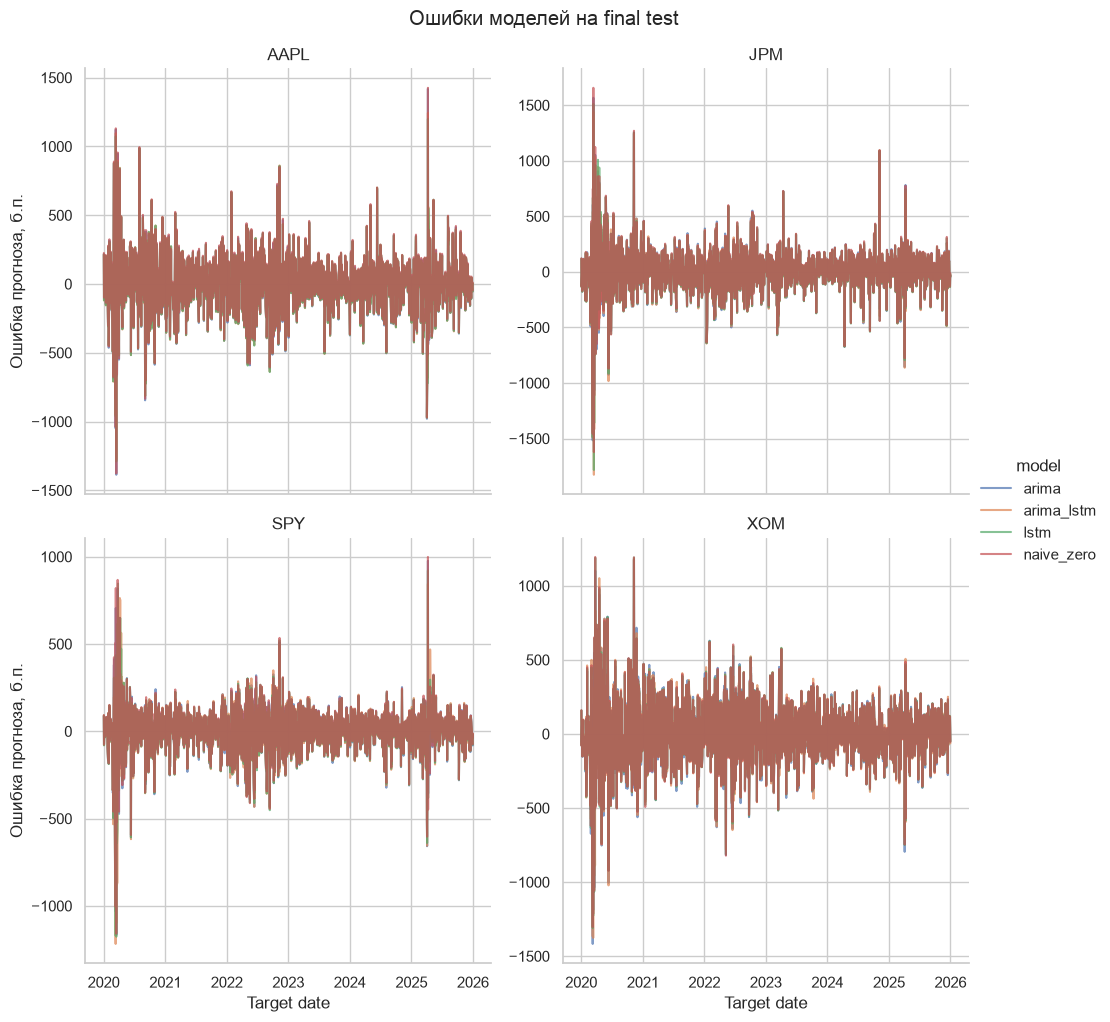

In [13]:
errors = predictions.assign(
    error_bps=(predictions["actual_return"] - predictions["predicted_return"]) * BPS_FACTOR
)
grid = sns.relplot(
    data=errors,
    x="target_date",
    y="error_bps",
    hue="model",
    col="ticker",
    col_wrap=2,
    kind="line",
    alpha=0.7,
    facet_kws={"sharey": False},
)
grid.set_axis_labels("Target date", "Ошибка прогноза, б.п.")
grid.set_titles("{col_name}")
grid.figure.suptitle("Ошибки моделей на final test", y=1.02)
plt.show()

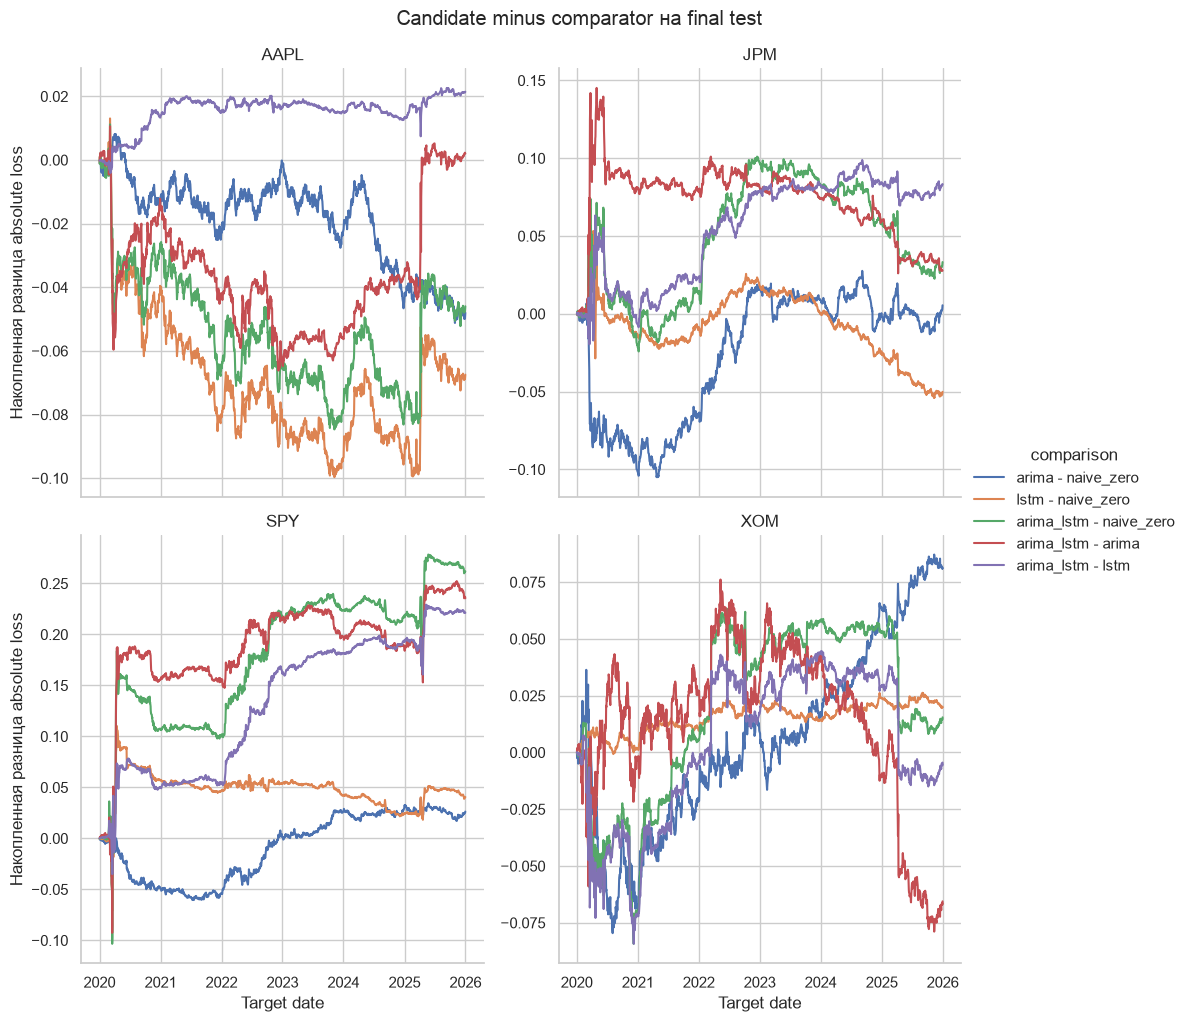

In [14]:
absolute_losses = predictions.assign(
    absolute_loss=(predictions["actual_return"] - predictions["predicted_return"]).abs()
).pivot(index=["ticker", "target_date"], columns="model", values="absolute_loss")
cumulative_frames = []
for candidate, comparator in MODEL_COMPARISONS:
    differential = (absolute_losses[candidate] - absolute_losses[comparator]).rename(
        "loss_difference"
    )
    frame = differential.reset_index()
    frame["comparison"] = f"{candidate} - {comparator}"
    frame["cumulative_loss_difference"] = frame.groupby("ticker")["loss_difference"].cumsum()
    cumulative_frames.append(frame)
cumulative_loss = pd.concat(cumulative_frames, ignore_index=True)

grid = sns.relplot(
    data=cumulative_loss,
    x="target_date",
    y="cumulative_loss_difference",
    hue="comparison",
    col="ticker",
    col_wrap=2,
    kind="line",
    facet_kws={"sharey": False},
)
grid.set_axis_labels("Target date", "Накопленная разница absolute loss")
grid.set_titles("{col_name}")
grid.figure.suptitle("Candidate minus comparator на final test", y=1.02)
plt.show()

## Правила интерпретации H1–H4

- **H1:** поддерживается только для модели, у которой эффект относительно `naive_zero` направлен в сторону меньшей ошибки и подтверждается размером эффекта, bootstrap-интервалом и Holm-adjusted DM; одно первое место в таблице недостаточно.
- **H2:** оценивается двумя заранее заданными сравнениями ARIMA-LSTM с ARIMA и LSTM. Отрицательная разница без статистической и практической значимости не считается подтверждением преимущества гибрида.
- **H3:** оценивается по заранее зафиксированным low/medium/high режимам. Границы режимов после просмотра final test не меняются; отсутствие устойчивой смены ранжирования отражается как неподтверждённая гипотеза.
- **H4:** учитывает согласованность ticker-level результатов и полный разброс десяти seed ordinary LSTM и десяти seed-level гибридов. Лучший отдельный seed не выбирается.

Отрицательные, смешанные и статистически незначимые результаты записываются без изменения моделей или протокола. Любой дополнительный анализ после этого запуска помечается как exploratory.

## Выводы по final test

- **H1 не подтверждена.** На pooled test LSTM снизила MAE относительно `naive_zero` на 0.095 б.п. (125.376 против 125.471 б.п.), но увеличила RMSE на 0.197 б.п. ARIMA и ARIMA-LSTM не улучшили обе основные метрики. Все Holm-adjusted DM p-value для сравнений с baseline превышают 0.05, а bootstrap-интервалы для улучшений включают ноль.
- **H2 не подтверждена.** ARIMA-LSTM получила pooled MAE 125.909 б.п. и RMSE 187.914 б.п., то есть уступила ARIMA (125.578 и 186.378 б.п.) и LSTM (125.376 и 186.556 б.п.). Для RMSE разница ARIMA-LSTM минус LSTM равна 1.36 б.п.; 95%-й bootstrap-интервал [0.43; 2.36] б.п. полностью находится выше нуля.
- **H3 поддерживается описательно.** По pooled MAE лучший результат показали ARIMA-LSTM в low-режиме, LSTM в medium-режиме и ARIMA в high-режиме. Разница между первым и вторым местом составляет 0.026–0.331 б.п. Отдельный статистический тест по режимам протоколом не предусмотрен, поэтому вывод относится к смене ранжирования, а не к доказанному преимуществу модели внутри режима.
- **H4 не подтверждена.** Стандартное отклонение MAE между десятью seed составляет 0.090–0.896 б.п. для LSTM и 0.143–1.985 б.п. для ARIMA-LSTM, но победитель меняется между тикерами и метриками. На AAPL LSTM имеет положительный OOS R² 0.0167, на JPM, SPY и XOM её OOS R² отрицателен; единообразного преимущества между активами нет.

Итог: на независимом периоде 2020–2025 ни одна обучаемая модель не снизила обе pooled-метрики относительно нулевого прогноза с подтверждением по заранее заданным статистическим процедурам. Минимальную pooled MAE получила LSTM, но выигрыш составил 0.095 б.п. и сопровождался увеличением RMSE на 0.197 б.п. Наблюдавшееся на validation преимущество гибрида не перенеслось на final test.